Image loaded with shape: (1024, 1536, 3)
Running KMeans clustering with k=4...


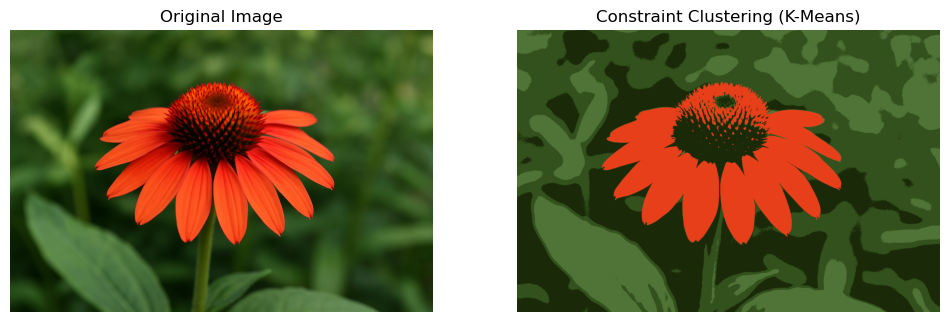

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

def kmeans_clustering(image_path, k=4):
    img = cv2.imread(image_path)
    if img is None:
        raise Exception("Image not found.")

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    print(f"Image loaded with shape: {img.shape}")

    pixel_values = img.reshape((-1, 3))
    pixel_values = np.float32(pixel_values)

    print(f"Running KMeans clustering with k={k}...")
    kmeans = KMeans(n_clusters=k, random_state=0).fit(pixel_values)

    segmented = kmeans.cluster_centers_[kmeans.labels_]
    segmented = segmented.reshape(img.shape).astype(np.uint8)

    # Plot results
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(segmented)
    plt.title("Constraint Clustering (K-Means)")
    plt.axis("off")

    plt.savefig("output_kmeans.png")
    plt.show()


if __name__ == "__main__":
    image_path = "img.png"  # Change to your image path
    kmeans_clustering(image_path, k=4)
